# Experiment 03: Bit-Flip Noise Analysis

## Objective

The objective of this experiment is to study the effect of bit-flip noise on an entangled Bell State and compare its behavior with depolarizing noise.

Bit-flip noise represents one of the simplest quantum error models, where qubit states are randomly flipped between |0⟩ and |1⟩.

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.circuits import bell_state_circuit
from src.noise_models import create_bit_flip_noise

from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt
import numpy as np

In [21]:
qc = bell_state_circuit()

ideal_simulator = AerSimulator()

ideal_counts = ideal_simulator.run(
    qc,
    shots=10000
).result().get_counts()

ideal_counts

{'00': 5006, '11': 4994}

In [23]:
noise_probability = 0.30

noise_model = create_bit_flip_noise(
    noise_probability
)

noise_simulator = AerSimulator(
    noise_model=noise_model
)

noisy_counts = noise_simulator.run(
    qc,
    shots=10000
).result().get_counts()

print(noisy_counts)

{'10': 2161, '11': 2914, '01': 2069, '00': 2856}


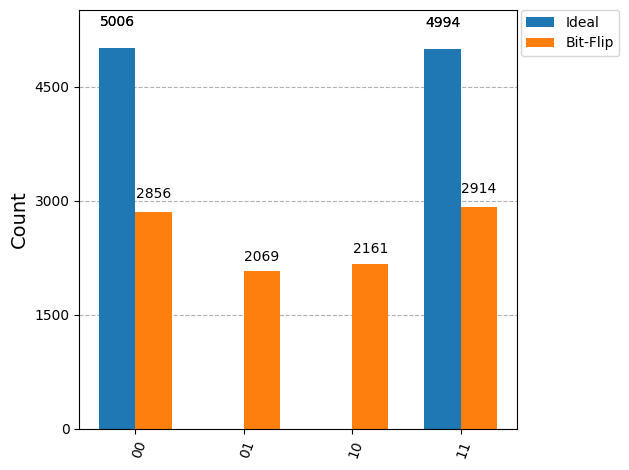

In [24]:
fig = plot_histogram(
    [ideal_counts, noisy_counts],
    legend=["Ideal","Bit-Flip"]
)
fig.savefig(
    "../results/bit_flip_histogram.png"
)
fig

In [25]:
probabilities = np.linspace(
    0,
    0.30,
    10
)

p00 = []
p11 = []
p01 = []
p10 = []

In [26]:
for p in probabilities:

    noise_model = create_bit_flip_noise(p)

    simulator = AerSimulator(
        noise_model=noise_model
    )

    counts = simulator.run(
        qc,
        shots=10000
    ).result().get_counts()

    p00.append(
        counts.get("00", 0) / 10000
    )

    p11.append(
        counts.get("11", 0) / 10000
    )

    p01.append(
        counts.get("01", 0) / 10000
    )

    p10.append(
        counts.get("10", 0) / 10000
    )

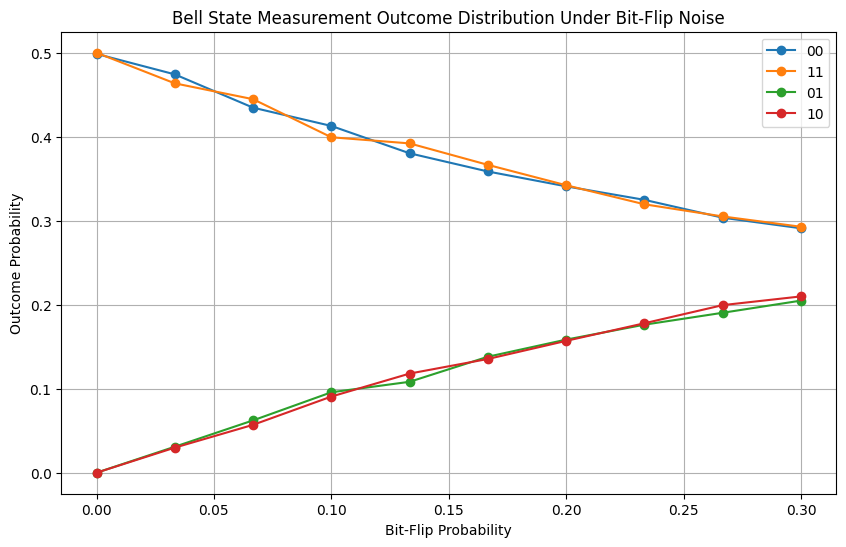

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    probabilities,
    p00,
    marker='o',
    label='00'
)

plt.plot(
    probabilities,
    p11,
    marker='o',
    label='11'
)

plt.plot(
    probabilities,
    p01,
    marker='o',
    label='01'
)

plt.plot(
    probabilities,
    p10,
    marker='o',
    label='10'
)

plt.xlabel(
    "Bit-Flip Probability"
)

plt.ylabel(
    "Outcome Probability"
)

plt.title(
    "Bell State Measurement Outcome Distribution Under Bit-Flip Noise"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../results/bit_flip_probability_distribution.png"
)

plt.show()

In [16]:
import pandas as pd

results_df = pd.DataFrame({
    "Bit-Flip Probability": probabilities,
    "P(00)": p00,
    "P(11)": p11,
    "P(01)": p01,
    "P(10)": p10
})

results_df

,Bit-Flip Probability,P(00),P(11),P(01),P(10)
0,0.000000,4.998,5.002,0.000,0.000
1,0.033333,4.649,4.719,0.308,0.324
2,0.066667,4.352,4.401,0.633,0.614
3,0.100000,4.073,4.081,0.911,0.935
4,0.133333,3.906,3.803,1.134,1.157
5,0.166667,3.590,3.596,1.381,1.433
6,0.200000,3.436,3.452,1.611,1.501
7,0.233333,3.255,3.138,1.791,1.816
8,0.266667,3.017,3.095,1.961,1.927
9,0.300000,2.825,2.942,2.205,2.028


## Analysis

The ideal Bell State produces only the outcomes 00 and 11 with approximately equal probability.

As the bit-flip probability increases, the probabilities of the correct Bell State outcomes decrease while the probabilities of the error states 01 and 10 increase.

The probability distribution plot demonstrates a gradual transfer of probability from the desired outcomes to the erroneous outcomes. This behavior is consistent with the expected action of bit-flip noise, which randomly flips qubit states between |0⟩ and |1⟩.

Unlike depolarizing noise, bit-flip noise introduces structured and predictable errors, making the resulting error patterns easier to identify and analyze.

## Conclusion

This experiment investigated the impact of bit-flip noise on an entangled Bell State.

The results showed that increasing bit-flip probability reduces the likelihood of observing the correct Bell State outcomes while increasing the occurrence of erroneous measurement states.

The observed behavior matched the theoretical expectations of bit-flip errors and highlighted the importance of quantum error correction techniques for preserving quantum information in noisy quantum systems.

Compared with the depolarizing noise experiment, bit-flip noise produced more structured error patterns. The appearance and growth of the 01 and 10 states clearly illustrate how specific quantum error channels affect measurement outcomes differently.

This distinction is important because different noise mechanisms require different error correction and mitigation strategies.